In [12]:
import os
import numpy as np
import cv2
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras_facenet import FaceNet

# Initialize Core Components
path = kagglehub.dataset_download("jensdhondt/extendedyaleb-cropped-full")
cropped_path = os.path.join(path, 'cropped')
embedder = FaceNet()
le = LabelEncoder()

Using Colab cache for faster access to the 'extendedyaleb-cropped-full' dataset.


In [13]:
def recover_shadows(img_path):
    """Applies Gamma Correction and CLAHE to recover facial features from shadows."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    # Gamma Correction (Gamma=1.5)
    gamma = 1.5
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    img = cv2.LUT(img, table)
    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = cv2.resize(img, (160, 160))
    return img

def advanced_data_generator(tasks, batch_size=32):
    """Memory-efficient generator for real-time preprocessing."""
    num_samples = len(tasks)
    while True:
        np.random.shuffle(tasks)
        for offset in range(0, num_samples, batch_size):
            batch_samples = tasks[offset:offset + batch_size]
            images, labels = [], []
            for img_path, label in batch_samples:
                img = recover_shadows(img_path)
                if img is not None:
                    img = (img.astype(np.float32) - 127.5) / 128.0
                    images.append(img)
                    labels.append(le.transform([label])[0])
            yield np.array(images), np.array(labels)

In [14]:
# Prepare Tasks and Perform 80/10/10 Split
subdirs = sorted([s for s in os.listdir(cropped_path) if os.path.isdir(os.path.join(cropped_path, s))])
all_tasks = [(os.path.join(cropped_path, s, f), s) for s in subdirs for f in os.listdir(os.path.join(cropped_path, s)) if f.endswith('.pgm') and 'Ambient' not in f]
le.fit([t[1] for t in all_tasks])

train_tasks, temp_tasks = train_test_split(all_tasks, test_size=0.20, random_state=42)
val_tasks, test_tasks = train_test_split(temp_tasks, test_size=0.50, random_state=42)

print(f"Setup complete. Train: {len(train_tasks)}, Val: {len(val_tasks)}, Test: {len(test_tasks)}")

Setup complete. Train: 12902, Val: 1613, Test: 1613


In [15]:
# Define Model with Fine-Tuning enabled for top layers
base_model = embedder.model
base_model.trainable = True
for layer in base_model.layers[:-20]: layer.trainable = False

model = models.Sequential([
    base_model,
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    layers.Dropout(0.5),
    layers.Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [16]:
# Train and Evaluate
model.fit(advanced_data_generator(train_tasks),
          steps_per_epoch=len(train_tasks)//32,
          validation_data=advanced_data_generator(val_tasks),
          validation_steps=len(val_tasks)//32,
          epochs=10,
          verbose=1)

loss, acc = model.evaluate(advanced_data_generator(test_tasks), steps=len(test_tasks)//32)
print(f"\nFinal Test Accuracy: {acc*100:.2f}%")

Epoch 1/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 73s 126ms/step - accuracy: 0.4808 - loss: 2.3347 - val_accuracy: 0.9506 - val_loss: 2.1944
Epoch 2/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 53s 110ms/step - accuracy: 0.9190 - loss: 0.8377 - val_accuracy: 0.9644 - val_loss: 0.5284
Epoch 3/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 43s 107ms/step - accuracy: 0.9531 - loss: 0.5669 - val_accuracy: 0.9719 - val_loss: 0.4179
Epoch 4/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 86s 213ms/step - accuracy: 0.9611 - loss: 0.4774 - val_accuracy: 0.9715 - val_loss: 0.3888
Epoch 5/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 42s 105ms/step - accuracy: 0.9677 - loss: 0.4305 - val_accuracy: 0.9744 - val_loss: 0.3696
Epoch 6/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 42s 104ms/step - accuracy: 0.9710 - loss: 0.3985 - val_accuracy: 0.9741 - val_loss: 0.3596
Epoch 7/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.9739 - loss: 0.3802 - val_accuracy: 0.9772 - val_loss: 0.3515
Epoch 8/10
403/403 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.9772 - loss: 0

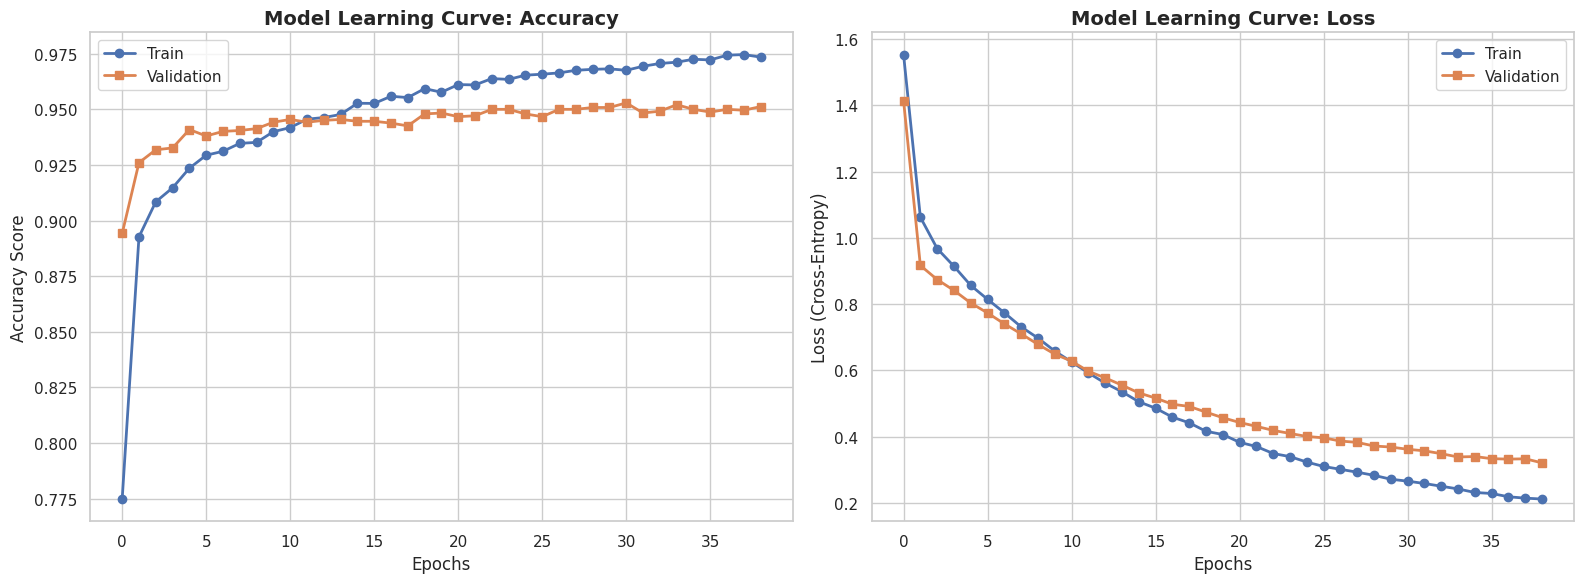

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional plot style
sns.set_theme(style="whitegrid")

def plot_training_results(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train', linewidth=2, marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2, marker='s')
    ax1.set_title('Model Learning Curve: Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Accuracy Score', fontsize=12)
    ax1.legend(frameon=True)

    # Loss
    ax2.plot(history.history['loss'], label='Train', linewidth=2, marker='o')
    ax2.plot(history.history['val_loss'], label='Validation', linewidth=2, marker='s')
    ax2.set_title('Model Learning Curve: Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss (Cross-Entropy)', fontsize=12)
    ax2.legend(frameon=True)

    plt.tight_layout()
    plt.show()

# We check for history object from the fit command
if 'history' in globals():
    plot_training_results(history)
else:
    print("Note: To see plots, please ensure training was run as 'history = model.fit(...)'")

Evaluating model on test set...


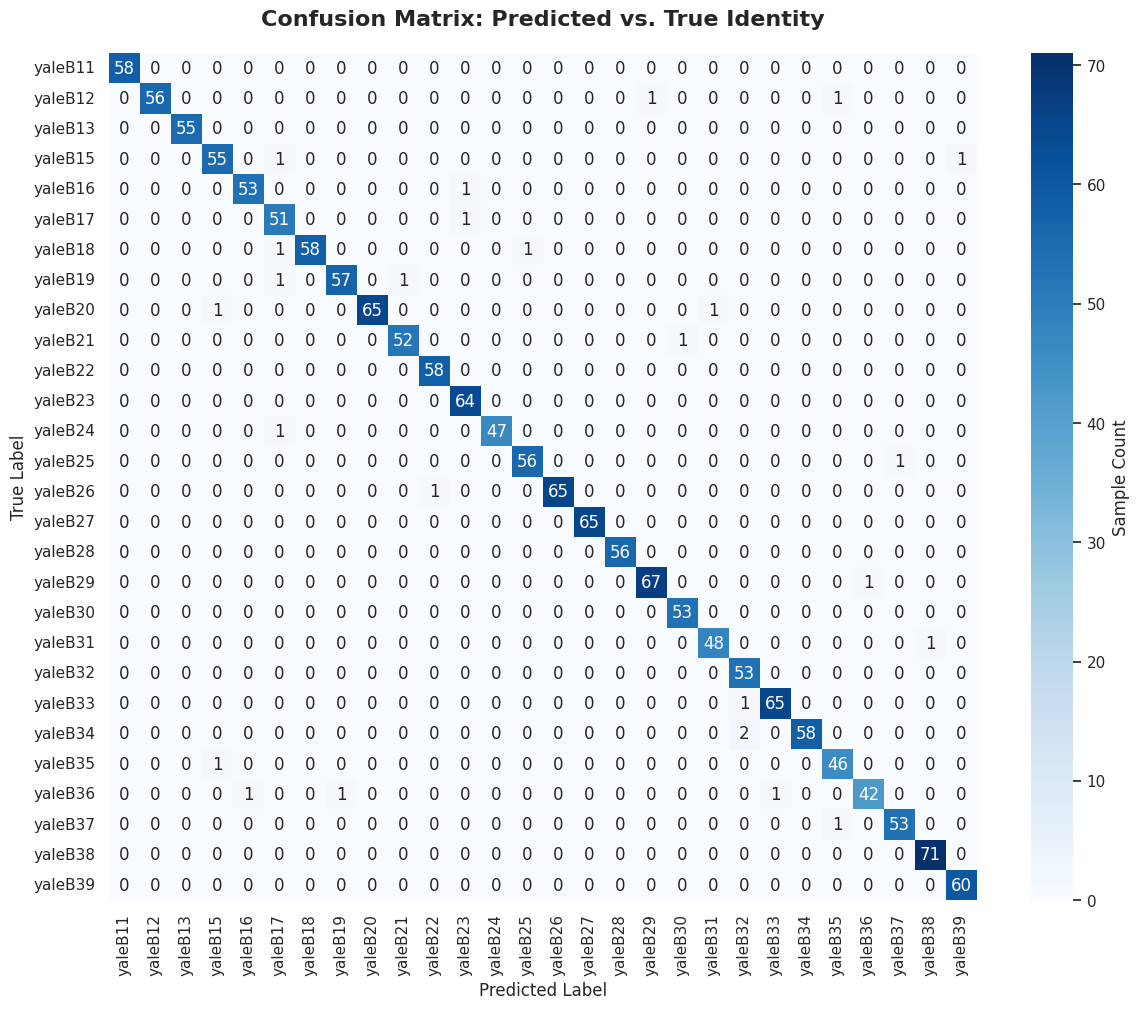


       DETAILED CLASSIFICATION PERFORMANCE
              precision    recall  f1-score   support

     yaleB11       1.00      1.00      1.00        58
     yaleB12       1.00      0.97      0.98        58
     yaleB13       1.00      1.00      1.00        55
     yaleB15       0.96      0.96      0.96        57
     yaleB16       0.98      0.98      0.98        54
     yaleB17       0.93      0.98      0.95        52
     yaleB18       1.00      0.97      0.98        60
     yaleB19       0.98      0.97      0.97        59
     yaleB20       1.00      0.97      0.98        67
     yaleB21       0.98      0.98      0.98        53
     yaleB22       0.98      1.00      0.99        58
     yaleB23       0.97      1.00      0.98        64
     yaleB24       1.00      0.98      0.99        48
     yaleB25       0.98      0.98      0.98        57
     yaleB26       1.00      0.98      0.99        66
     yaleB27       1.00      1.00      1.00        65
     yaleB28       1.00      1.00    

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

def plot_advanced_evaluation(model, tasks):
    print("Evaluating model on test set...")
    y_true, y_pred = [], []
    test_gen = advanced_data_generator(tasks, batch_size=1)

    for _ in range(len(tasks)):
        img, label = next(test_gen)
        pred = model.predict(img, verbose=0)
        y_true.append(label[0])
        y_pred.append(np.argmax(pred))

    # 1. Confusion Matrix
    plt.figure(figsize=(14, 11))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, cbar_kws={'label': 'Sample Count'})
    plt.title('Confusion Matrix: Predicted vs. True Identity', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

    # 2. Classification Report
    print("\n" + "="*60)
    print("       DETAILED CLASSIFICATION PERFORMANCE")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=le.classes_))

plot_advanced_evaluation(model, test_tasks)

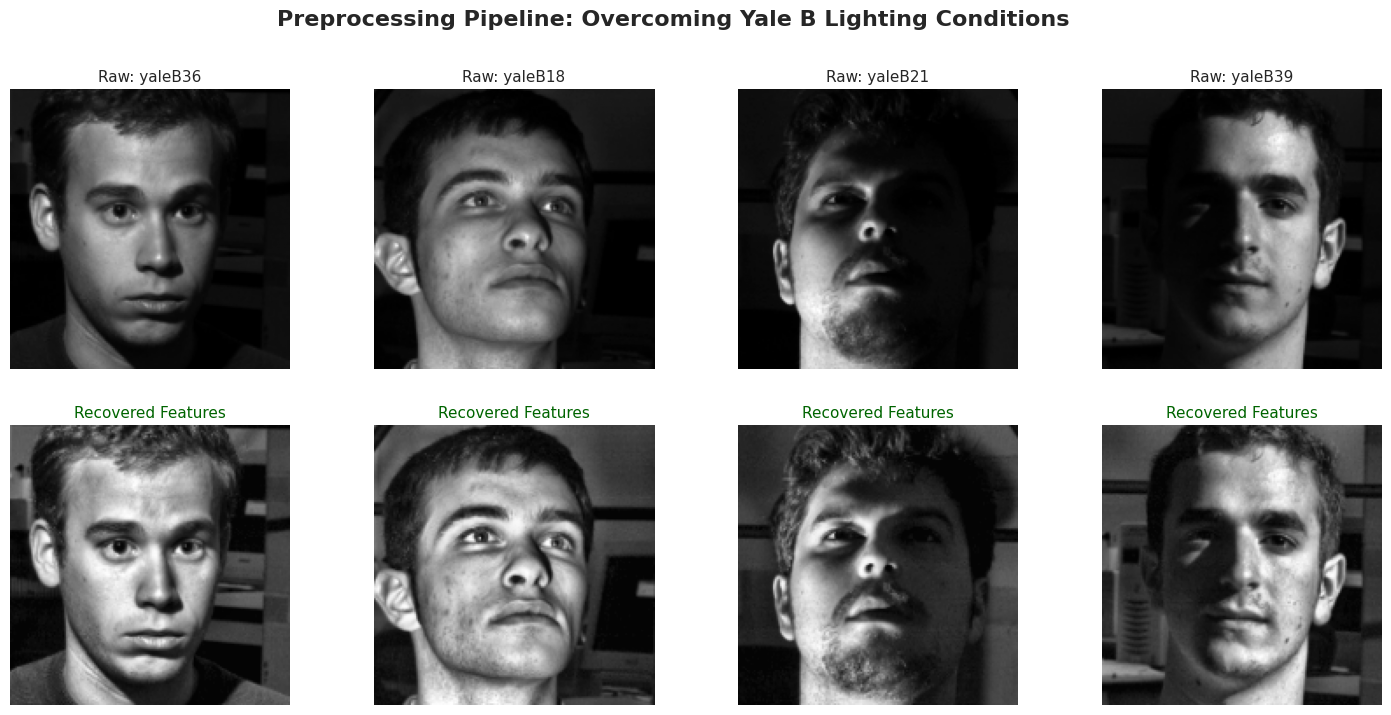

In [23]:
def visualize_shadow_recovery_effect(tasks, n=4):
    """Visualizes the raw Yale B input vs the shadow-recovered output."""
    indices = np.random.choice(len(tasks), n, replace=False)
    fig, axes = plt.subplots(2, n, figsize=(18, 8))

    for i, idx in enumerate(indices):
        img_path, label = tasks[idx]

        # Original (Raw PGM)
        orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        orig_resized = cv2.resize(orig, (160, 160))

        # Processed (Gamma + CLAHE)
        proc = recover_shadows(img_path)

        axes[0, i].imshow(orig_resized, cmap='gray')
        axes[0, i].set_title(f"Raw: {label}", fontsize=11)
        axes[0, i].axis('off')

        axes[1, i].imshow(proc)
        axes[1, i].set_title("Recovered Features", fontsize=11, color='darkgreen')
        axes[1, i].axis('off')

    plt.suptitle("Preprocessing Pipeline: Overcoming Yale B Lighting Conditions", fontsize=16, fontweight='bold')
    plt.subplots_adjust(top=0.88)
    plt.show()

visualize_shadow_recovery_effect(test_tasks)

In [20]:
from sklearn.metrics import classification_report

def show_classification_report(model, tasks):
    print("Collecting metrics for classification report...")
    y_true = []
    y_pred = []

    test_gen = advanced_data_generator(tasks, batch_size=1)
    for _ in range(len(tasks)):
        img, label = next(test_gen)
        pred = model.predict(img, verbose=0)
        y_true.append(label[0])
        y_pred.append(np.argmax(pred))

    report = classification_report(y_true, y_pred, target_names=le.classes_)
    print("\nDetailed Classification Report:\n")
    print(report)

show_classification_report(model, test_tasks)


Detailed Classification Report:

              precision    recall  f1-score   support

     yaleB11       1.00      1.00      1.00        58
     yaleB12       1.00      0.97      0.98        58
     yaleB13       1.00      1.00      1.00        55
     yaleB15       0.96      0.96      0.96        57
     yaleB16       0.98      0.98      0.98        54
     yaleB17       0.93      0.98      0.95        52
     yaleB18       1.00      0.97      0.98        60
     yaleB19       0.98      0.97      0.97        59
     yaleB20       1.00      0.97      0.98        67
     yaleB21       0.98      0.98      0.98        53
     yaleB22       0.98      1.00      0.99        58
     yaleB23       0.97      1.00      0.98        64
     yaleB24       1.00      0.98      0.99        48
     yaleB25       0.98      0.98      0.98        57
     yaleB26       1.00      0.98      0.99        66
     yaleB27       1.00      1.00      1.00        65
     yaleB28       1.00      1.00      1.00    